In [1]:
import pandas as pd
import numpy as np
import ast
from collections import Counter
import itertools

# Load the new merged csv file for further EDA
eda_csv = r"D:\BPS\dataset\2025\all_attack_benign_samples\dataset_1sec_benign_ddos.csv"

df_iiot = pd.read_csv(eda_csv)


df_iiot.shape
df_iiot.head()

,device_name,device_mac,timestamp,timestamp_start,timestamp_end,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types,...,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation,target
0,edge1,dc:a6:32:dc:27:d4,2025-01-23T15:31:10.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:10.709000Z,2025-01-23T15:31:11.709000Z,0.0,0.0,0.0,0.0,[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,edge1,dc:a6:32:dc:27:d4,2025-01-23T15:31:11.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:11.709000Z,2025-01-23T15:31:12.709000Z,0.0,0.0,0.0,0.0,[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,edge1,dc:a6:32:dc:27:d4,2025-01-23T15:31:12.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:12.709000Z,2025-01-23T15:31:13.709000Z,0.0,0.0,0.0,0.0,[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,edge1,dc:a6:32:dc:27:d4,2025-01-23T15:31:13.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:13.709000Z,2025-01-23T15:31:14.709000Z,0.0,0.0,0.0,0.0,[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,edge1,dc:a6:32:dc:27:d4,2025-01-23T15:31:14.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:14.709000Z,2025-01-23T15:31:15.709000Z,0.0,0.0,0.0,0.0,[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [2]:
import numpy as np

numeric_cols = df_iiot.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)
print(f"{len(numeric_cols)}")

['log_data-ranges_avg', 'log_data-ranges_max', 'log_data-ranges_min', 'log_data-ranges_std_deviation', 'log_data-types_count', 'log_interval-messages', 'log_messages_count', 'network_fragmentation-score', 'network_fragmented-packets', 'network_header-length_avg', 'network_header-length_max', 'network_header-length_min', 'network_header-length_std_deviation', 'network_interval-packets', 'network_ip-flags_avg', 'network_ip-flags_max', 'network_ip-flags_min', 'network_ip-flags_std_deviation', 'network_ip-length_avg', 'network_ip-length_max', 'network_ip-length_min', 'network_ip-length_std_deviation', 'network_ips_all_count', 'network_ips_dst_count', 'network_ips_src_count', 'network_macs_all_count', 'network_macs_dst_count', 'network_macs_src_count', 'network_mss_avg', 'network_mss_max', 'network_mss_min', 'network_mss_std_deviation', 'network_packet-size_avg', 'network_packet-size_max', 'network_packet-size_min', 'network_packet-size_std_deviation', 'network_packets_all_count', 'network_

In [3]:
object_cols = df_iiot.select_dtypes(include=["object"]).columns.tolist()

print(object_cols)
print(f"{len(object_cols)}")

['device_name', 'device_mac', 'timestamp', 'timestamp_start', 'timestamp_end', 'log_data-types', 'network_ips_all', 'network_ips_dst', 'network_ips_src', 'network_macs_all', 'network_macs_dst', 'network_macs_src', 'network_ports_all', 'network_ports_dst', 'network_ports_src', 'network_protocols_all', 'network_protocols_dst', 'network_protocols_src']
18


In [4]:
# List columns 
object_cols = df_iiot.select_dtypes(include="object").columns

for col in object_cols:
    cols_to_check = df_iiot[col].dropna().astype(str).iloc[0] if not df_iiot[col].dropna().empty else None
#    print(f"{col}: {cols_to_check}")

In [5]:
# https://note.nkmk.me/en/python-ast-literal-eval/ 
# Before saving a new csv file on the IIoT_1_merge_benign_ddos.ipynb some columns were identifies as lists. 
# When saving a new csv file, Python transforms these lists into strings
# # literal_eval converts columns back to lists

import ast

list_cols = [
    "log_data-types",
    "network_ips_all",
    "network_ips_dst",
    "network_ips_src",
    "network_macs_all",
    "network_macs_dst",
    "network_macs_src",
    "network_ports_all",
    "network_ports_dst",
    "network_ports_src",
    "network_protocols_all",
    "network_protocols_dst",
    "network_protocols_src"
]

for col in list_cols:
    if col in df_iiot.columns:
        df_iiot[col] = df_iiot[col].apply(ast.literal_eval)

In [6]:
for col in df_iiot.columns:
    print(col)

device_name
device_mac
timestamp
timestamp_start
timestamp_end
log_data-ranges_avg
log_data-ranges_max
log_data-ranges_min
log_data-ranges_std_deviation
log_data-types
log_data-types_count
log_interval-messages
log_messages_count
network_fragmentation-score
network_fragmented-packets
network_header-length_avg
network_header-length_max
network_header-length_min
network_header-length_std_deviation
network_interval-packets
network_ip-flags_avg
network_ip-flags_max
network_ip-flags_min
network_ip-flags_std_deviation
network_ip-length_avg
network_ip-length_max
network_ip-length_min
network_ip-length_std_deviation
network_ips_all
network_ips_all_count
network_ips_dst
network_ips_dst_count
network_ips_src
network_ips_src_count
network_macs_all
network_macs_all_count
network_macs_dst
network_macs_dst_count
network_macs_src
network_macs_src_count
network_mss_avg
network_mss_max
network_mss_min
network_mss_std_deviation
network_packet-size_avg
network_packet-size_max
network_packet-size_min
netw

In [7]:
# Check how traffic class is distributed
df_iiot["target"].value_counts()

target
0    136800
1     18056
Name: count, dtype: int64

In [8]:
# Check for Nan values 
print("\nMissing values:")
print(df_iiot.isna().sum())

df_iiot.head()


Missing values:
device_name                          0
device_mac                           0
timestamp                            0
timestamp_start                      0
timestamp_end                        0
                                    ..
network_window-size_avg              0
network_window-size_max              0
network_window-size_min              0
network_window-size_std_deviation    0
target                               0
Length: 90, dtype: int64


,device_name,device_mac,timestamp,timestamp_start,timestamp_end,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types,...,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation,target
0,edge1,dc:a6:32:dc:27:d4,2025-01-23T15:31:10.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:10.709000Z,2025-01-23T15:31:11.709000Z,0.0,0.0,0.0,0.0,[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,edge1,dc:a6:32:dc:27:d4,2025-01-23T15:31:11.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:11.709000Z,2025-01-23T15:31:12.709000Z,0.0,0.0,0.0,0.0,[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,edge1,dc:a6:32:dc:27:d4,2025-01-23T15:31:12.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:12.709000Z,2025-01-23T15:31:13.709000Z,0.0,0.0,0.0,0.0,[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,edge1,dc:a6:32:dc:27:d4,2025-01-23T15:31:13.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:13.709000Z,2025-01-23T15:31:14.709000Z,0.0,0.0,0.0,0.0,[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,edge1,dc:a6:32:dc:27:d4,2025-01-23T15:31:14.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:14.709000Z,2025-01-23T15:31:15.709000Z,0.0,0.0,0.0,0.0,[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [9]:
# same as IOT
import numpy as np
#identify and filter numerical columns for further EDA 
numerical_columns = df_iiot.select_dtypes(include=[np.number]).columns.tolist()
X_iiot = df_iiot[numerical_columns]


In [10]:
# code for IoT - stats_iot = X_iot.agg(["mean", "median", "std", "var"]).T
# stats_iot_sorted = stats_iot.sort_values("std", ascending=False)


stats_tbl = X_iiot.agg(["mean", "median", "std", "var"]).T

stats_tbl_sorted = stats_tbl.sort_values("std", ascending=False)
pd.set_option('display.max_rows', None)
stats_tbl_sorted

,mean,median,std,var
network_window-size_max,18880.739952,0.000000,28978.624764,8.397607e+08
network_packets_all_count,6427.816649,1.000000,26416.834004,6.978491e+08
network_packets_dst_count,6261.968777,0.000000,25980.309269,6.749765e+08
network_window-size_avg,10067.487313,0.000000,16050.508341,2.576188e+08
network_tcp-flags-rst_count,1368.284103,0.000000,13658.980488,1.865677e+08
network_tcp-flags-fin_count,1265.472355,0.000000,13587.125114,1.846100e+08
network_window-size_std_deviation,8230.936742,0.000000,12980.792934,1.685010e+08
network_ports_all_count,1962.238350,0.000000,9959.859407,9.919880e+07
network_ports_src_count,1901.020845,0.000000,9896.158301,9.793395e+07
network_tcp-flags-ack_count,1082.298032,0.000000,9734.155254,9.475378e+07


### Outliers

In [11]:

X_iiot = df_iiot.select_dtypes(include="number").copy()


stats_tbl = X_iiot.agg(["mean", "median", "std", "var"]).T


stats_tbl_sorted = stats_tbl.sort_values(by="std", ascending=False)


top_features_iiot = stats_tbl_sorted.head(10).index.tolist()

In [12]:
# Check the outlier rate using IQR method
outlier_summary_iiot = {}

for f in top_features_iiot:
    x = df_iiot[f].dropna() #double ensuring, because there is no nan in the dataset

    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_rate = ((x < lower) | (x > upper)).mean()

    outlier_summary_iiot[f] = outlier_rate

outlier_rate_tbl_iiot = (
    pd.Series(outlier_summary_iiot, name="outlier_rate")
    .sort_values(ascending=False)
)

outlier_rate_tbl_iiot

network_packets_all_count            0.139181
network_packets_dst_count            0.138438
network_tcp-flags-ack_count          0.112362
network_ports_all_count              0.112162
network_ports_src_count              0.109385
network_tcp-flags-rst_count          0.052701
network_tcp-flags-fin_count          0.013735
network_window-size_max              0.000000
network_window-size_avg              0.000000
network_window-size_std_deviation    0.000000
Name: outlier_rate, dtype: float64

### Ports check

In [13]:
from collections import Counter
import itertools

dst_port_counts = Counter(
    itertools.chain.from_iterable(df_iiot["network_ports_dst"])
)

dst_port_counts.most_common(20)

[('1883', 45453),
 ('6667', 9414),
 ('9200', 7714),
 ('58645', 7312),
 ('52279', 7250),
 ('64724', 7249),
 ('59453', 7249),
 ('63207', 7241),
 ('63796', 7237),
 ('52392', 7226),
 ('57688', 7153),
 ('62577', 7026),
 ('52789', 6692),
 ('80', 3848),
 ('60036', 2487),
 ('8886', 1804),
 ('50920', 1265),
 ('62434', 1191),
 ('65464', 898),
 ('50523', 873)]

In [14]:
from collections import Counter
import itertools

# benign ports
benign_ports = Counter(
    itertools.chain.from_iterable(
        df_iiot[df_iiot["target"] == 0]["network_ports_dst"]
    )
).most_common(10)

# attack ports
attack_ports = Counter(
    itertools.chain.from_iterable(
        df_iiot[df_iiot["target"] == 1]["network_ports_dst"]
    )
).most_common(10)

print("Top-10 benign dst ports")
print(benign_ports)

print("\nTop-10 attack dst ports")
print(attack_ports)

Top-10 benign dst ports
[('1883', 38433), ('6667', 9260), ('52279', 7186), ('63207', 7184), ('64724', 7182), ('59453', 7171), ('58645', 7166), ('63796', 7150), ('52392', 7138), ('9200', 7050)]

Top-10 attack dst ports
[('1883', 7020), ('80', 3801), ('9200', 664), ('29811', 436), ('29813', 397), ('49612', 359), ('44884', 355), ('29812', 354), ('43554', 350), ('43584', 346)]


In [15]:
# Fixing memory error issue of applying .explode() method for every dst port. 
df_ports = (
    df_iiot[["network_ports_dst", "network_packets_all_count", "target"]]
    .explode("network_ports_dst")
)

In [16]:
# Fixing memory issues - Create a new df focused on the destination port
df_ports = df_iiot[["network_ports_dst", "network_packets_all_count", "target"]].copy()

# compute the number of destination port for each observation
# different from iot, this dataset present multiple ports in a single row 
df_ports["num_ports"] = df_ports["network_ports_dst"].apply(len)

# .explode() method will transform each single dst port in a row
df_ports = df_ports.explode("network_ports_dst")

# The volume without this part was extremely inflated, because it was considering the entire volume for all 
#ports identified in the same row. 
#The only difference now is that the packets count is devided by the amount of observed ports in that row 

df_ports["packets_per_port"] = df_ports["network_packets_all_count"] / df_ports["num_ports"]

# estimated traffic volume per port in the benign traffic 
benign_volume = (
    df_ports[df_ports["target"] == 0]
    .groupby("network_ports_dst")["packets_per_port"]
    .sum()
    .sort_values(ascending=False)
)

# estimated traffic volume per port in the ddos traffic 
attack_volume = (
    df_ports[df_ports["target"] == 1]
    .groupby("network_ports_dst")["packets_per_port"]
    .sum()
    .sort_values(ascending=False)
)


print("Benign dst ports")
print(benign_volume.head(10))

print("DDoS dst ports")
print(attack_volume.head(10))

Benign dst ports
network_ports_dst
1883     76925.286253
9200     30244.705193
57688    30241.159738
52789    20206.509109
52279    18698.782730
63207    18695.090072
62577    18168.533351
64724    16954.090811
59453    15148.521846
58645    15137.322312
Name: packets_per_port, dtype: float64
DDoS dst ports
network_ports_dst
1883     1.338347e+08
80       1.096795e+08
8886     2.411634e+06
50523    2.068657e+06
9200     1.990827e+06
50920    1.818870e+06
45010    1.393960e+06
63210    1.192214e+06
1900     1.161624e+06
65072    1.156707e+06
Name: packets_per_port, dtype: float64


#### The network packets (volume) does not reflect the exact volume per destination port. This is a characteristc of the dataset that may contain multiple ports in a row. Therefore, the method .explode() solves this problem by creating a new line for each each destination port. However, when exploring the distribution of packets across individual destination ports it is not possible to determine the exact amount of packets associated with unique destination ports. As a result, the analysis allows us to understand how destination ports and packets volume are associated, but does not provide an exact measurement of pckt volume per unique destination ports. 

### Feature redudancy - Correlation 

In [17]:
corr_iiot = X_iiot[top_features_iiot].corr(method="pearson")

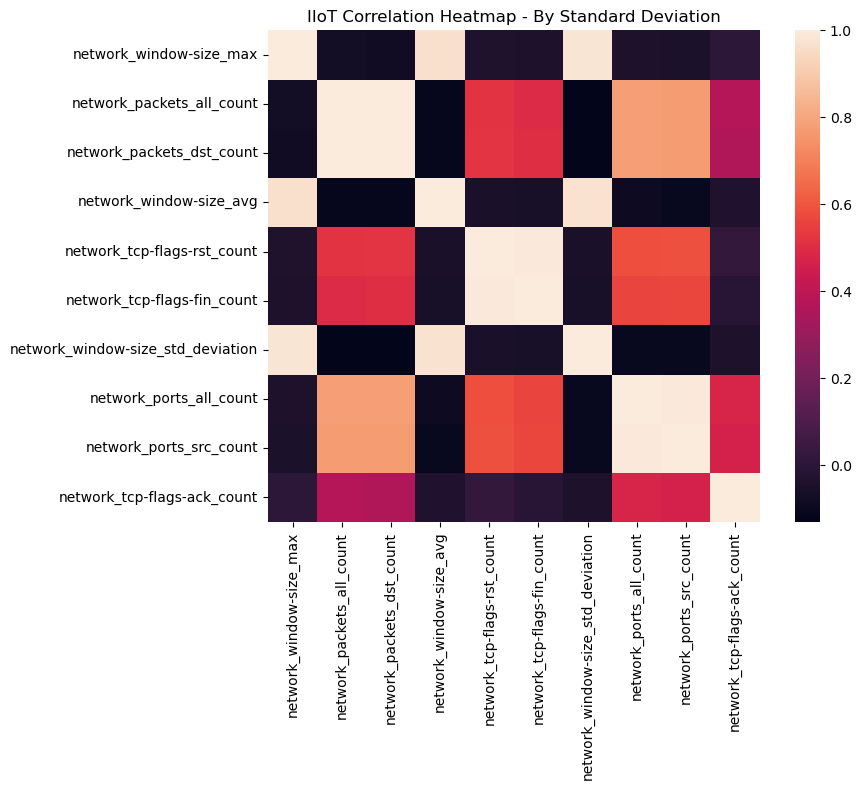

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_iiot,
    cmap="rocket",
    annot=False,
    square=True
)
plt.title("IIoT Correlation Heatmap - By Standard Deviation")
plt.tight_layout()
plt.savefig("correlation_heatmap_iiot.png", dpi=300, bbox_inches="tight")

plt.show()


In [19]:
#high correlated features. If one changes, so does the other. 
corr_pairs_iiot = (
    corr_iiot.abs()
    .where(lambda x: x < 1.0)
    .stack()
    .sort_values(ascending=False)
)

corr_pairs_iiot.head(20)


network_packets_dst_count          network_packets_all_count            0.997392
network_packets_all_count          network_packets_dst_count            0.997392
network_ports_all_count            network_ports_src_count              0.995084
network_ports_src_count            network_ports_all_count              0.995084
network_tcp-flags-rst_count        network_tcp-flags-fin_count          0.994045
network_tcp-flags-fin_count        network_tcp-flags-rst_count          0.994045
network_window-size_max            network_window-size_std_deviation    0.982235
network_window-size_std_deviation  network_window-size_max              0.982235
network_window-size_avg            network_window-size_std_deviation    0.970078
network_window-size_std_deviation  network_window-size_avg              0.970078
network_window-size_avg            network_window-size_max              0.966521
network_window-size_max            network_window-size_avg              0.966521
network_packets_dst_count   

In [20]:
# remove these columns because they are idetifiers and target will be analyzed further on 
identifiers_columns = {
    "device_name", "device_mac",
    "timestamp", "timestamp_start", "timestamp_end",
    "target"
}

In [21]:
# Features are grouped according to the dataset description 
feature_groups = {
    "Size_Length": [
        "network_header-length_avg", "network_header-length_max", "network_header-length_min", "network_header-length_std_deviation",
        "network_ip-length_avg", "network_ip-length_max", "network_ip-length_min", "network_ip-length_std_deviation",
        "network_mss_avg", "network_mss_max", "network_mss_min", "network_mss_std_deviation",
        "network_packet-size_avg", "network_packet-size_max", "network_packet-size_min", "network_packet-size_std_deviation",
        "network_payload-length_avg", "network_payload-length_max", "network_payload-length_min", "network_payload-length_std_deviation"
    ],

    "Packet_Traffic_Rate": [
        "network_packets_all_count", "network_packets_dst_count", "network_packets_src_count",
        "network_interval-packets"
    ],

    "Header_Flags": [
        "network_ip-flags_avg", "network_ip-flags_max", "network_ip-flags_min", "network_ip-flags_std_deviation",
        "network_tcp-flags-ack_count", "network_tcp-flags-fin_count", "network_tcp-flags-psh_count",
        "network_tcp-flags-rst_count", "network_tcp-flags-syn_count", "network_tcp-flags-urg_count",
        "network_tcp-flags_avg", "network_tcp-flags_max", "network_tcp-flags_min", "network_tcp-flags_std_deviation"
    ],

    "Timing_Control": [
        "network_time-delta_avg", "network_time-delta_max", "network_time-delta_min", "network_time-delta_std_deviation",
        "network_ttl_avg", "network_ttl_max", "network_ttl_min", "network_ttl_std_deviation",
        "network_window-size_avg", "network_window-size_max", "network_window-size_min", "network_window-size_std_deviation"
    ],

    "Address_Diversity": [
        "network_ips_all_count", "network_ips_dst_count", "network_ips_src_count",
        "network_macs_all_count", "network_macs_dst_count", "network_macs_src_count"
    ],

    "Network_Multiplexing": [
        "network_ports_all_count", "network_ports_dst_count", "network_ports_src_count",
        "network_protocols_all_count", "network_protocols_dst_count", "network_protocols_src_count"
    ]
}

In [22]:
# create a dictionary mapping each feature to  a group 
feature_to_group = {}

for group, features in feature_groups.items():
    for feature in features:
        feature_to_group[feature] = group

In [23]:
# check std
feature_std = df_iiot.std(numeric_only=True)

# Convert to DataFrame for easier manipulation
df_std = feature_std.reset_index()
df_std.columns = ["Feature", "Std"]

# Map each feature to its corresponding group
df_std["Group"] = df_std["Feature"].map(feature_to_group)

In [24]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# Structure of rbc effect is the same as IoT dataset
def rank_biserial_from_u(u_stat, n1, n2):
    u_min = min(u_stat, n1 * n2 - u_stat)
    return 1 - (2 * u_min) / (n1 * n2)


def classify_rbc(rbc):
    if pd.isna(rbc):
        return np.nan
    elif rbc >= 0.50:
        return "large"
    elif rbc >= 0.30:
        return "moderate"
    elif rbc >= 0.10:
        return "small"
    else:
        return "very_small"

# select all numerical features, except for target 
X = df_iiot.select_dtypes(include=[np.number]).drop(columns=["target"]).copy()
y = df_iiot["target"]

# Split the traffic classes 
X_benign = X[y == 0]
X_attack = X[y == 1]

# compute rbc effect size individualluy for each feature 
results = []

for col in X.columns:
    benign_col = (
        pd.to_numeric(X_benign[col], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    attack_col = (
        pd.to_numeric(X_attack[col], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    
    if (
        len(benign_col) < 2 or
        len(attack_col) < 2 or
        benign_col.nunique() <= 1 or
        attack_col.nunique() <= 1
    ):
        continue

    # Mann–Whitney U test
    u_stat, _ = mannwhitneyu(benign_col, attack_col, alternative="two-sided")

    # Rank-biserial correlation
    rbc = rank_biserial_from_u(u_stat, len(benign_col), len(attack_col))

    results.append({
        "feature": col,
        "effect_size_rbc": rbc,
        "effect_strength": classify_rbc(rbc),
        "median_benign": benign_col.median(),
        "median_attack": attack_col.median(),
        "mean_benign": benign_col.mean(),
        "mean_attack": attack_col.mean()
    })


results_df = (
    pd.DataFrame(results)
    .sort_values("effect_size_rbc", ascending=False)
    .reset_index(drop=True)
)
pd.set_option('display.max_rows', None)
display(results_df)

,feature,effect_size_rbc,effect_strength,median_benign,median_attack,mean_benign,mean_attack
0,network_packets_dst_count,0.845896,large,0.0,1.181700e+04,1.411433,53694.636298
1,network_packets_all_count,0.841127,large,0.0,1.191000e+04,2.976594,55105.160445
2,network_macs_all_count,0.751825,large,0.0,6.000000e+00,1.427814,5.375775
3,network_macs_src_count,0.751805,large,0.0,5.000000e+00,1.284561,4.956247
4,network_macs_dst_count,0.751805,large,0.0,5.000000e+00,1.284561,4.956247
5,network_ips_src_count,0.744274,large,0.0,5.000000e+00,1.305175,4.991471
6,network_ips_all_count,0.743752,large,0.0,6.000000e+00,1.403487,5.323770
7,network_ports_all_count,0.652184,large,0.0,1.940000e+03,1.162149,16820.192734
8,network_ports_src_count,0.646672,large,0.0,9.390000e+02,1.075541,16295.821334
9,network_packet-size_min,0.645940,large,0.0,6.000000e+01,43.088326,104.355117


In [25]:
# load a dataframe for discriminative power computed by rbc
df_rbc = results_df.rename(columns={
    "feature": "Feature",
    "effect_size_rbc": "RBC"
})

# map feature -> group 
df_rbc["Group"] = df_rbc["Feature"].map(feature_to_group)

In [26]:
group_rbc = (
    df_rbc
    .dropna(subset=["Group"])  
    .groupby("Group")["RBC"]
    .mean()
    .sort_values(ascending=False)
)

print(group_rbc)

Group
Address_Diversity       0.716404
Packet_Traffic_Rate     0.624320
Network_Multiplexing    0.516984
Size_Length             0.290619
Timing_Control          0.202700
Header_Flags            0.186816
Name: RBC, dtype: float64


In [27]:
group_counts = df_rbc["Group"].value_counts()
print(group_counts)

Group
Size_Length             20
Header_Flags            13
Timing_Control          12
Address_Diversity        6
Network_Multiplexing     6
Packet_Traffic_Rate      4
Name: count, dtype: int64


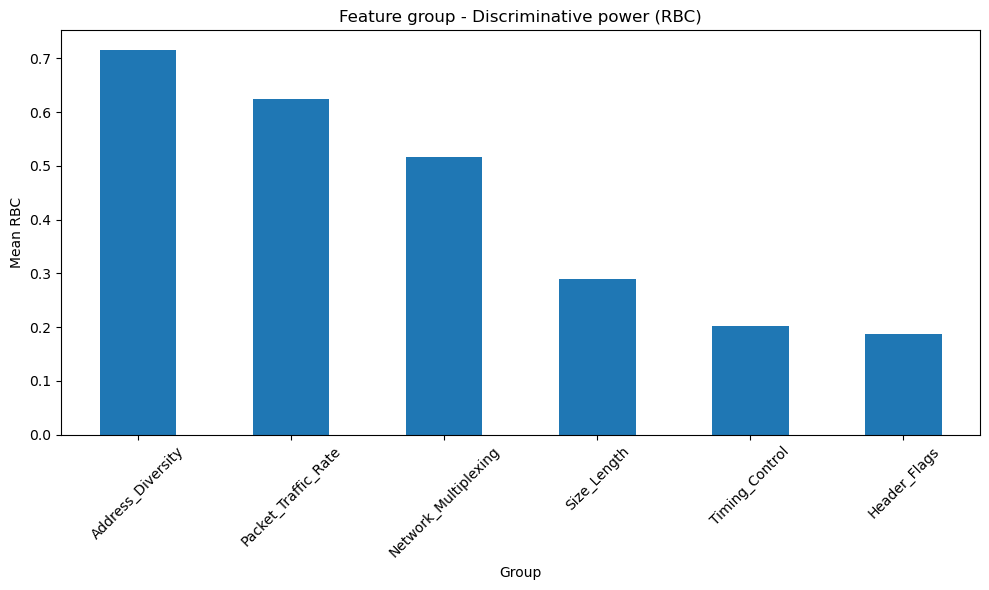

In [28]:
import matplotlib.pyplot as plt

group_rbc.plot(kind="bar", figsize=(10,6))

plt.ylabel("Mean RBC")
plt.title("Feature group - Discriminative power (RBC)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("iiot_group_rbc.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
group_rbc_std = (
    df_rbc
    .groupby("Group")["RBC"]
    .agg(["mean", "std"])
    .sort_values(by="mean", ascending=False)
)

print(group_rbc_std)

                          mean       std
Group                                   
Address_Diversity     0.716404  0.079182
Packet_Traffic_Rate   0.624320  0.256913
Network_Multiplexing  0.516984  0.160754
Size_Length           0.290619  0.177705
Timing_Control        0.202700  0.164224
Header_Flags          0.186816  0.119008


# Feature exploring for next step - Reducing the dataset

In [30]:
df_iiot["log_data-ranges_avg"].describe()

count    154856.000000
mean         57.724263
std         209.809769
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1208.000000
Name: log_data-ranges_avg, dtype: float64

In [31]:
df_iiot["log_data-types"].describe()

count     154856
unique         7
top           []
freq      118962
Name: log_data-types, dtype: object

In [32]:
df_iiot["log_data-types_count"].describe()

count    154856.000000
mean          0.283851
std           0.554440
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           2.000000
Name: log_data-types_count, dtype: float64

In [33]:
df_iiot["log_interval-messages"].describe()

count    154856.000000
mean          1.459719
std          24.313266
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         997.000000
Name: log_interval-messages, dtype: float64

In [34]:
df_iiot["log_messages_count"].describe()

count    154856.000000
mean          0.548070
std           1.732191
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         143.000000
Name: log_messages_count, dtype: float64

In [35]:
df_iiot[["log_messages_count", "log_interval-messages"]].corr()

,log_messages_count,log_interval-messages
log_messages_count,1.000000,0.151456
log_interval-messages,0.151456,1.000000


##### Log_interval-message and log_messages_count have low correlation, indicating that they represent different aspects in the traffic behavior. Therefore, both features will remain in the dataset due to the absence of redundancy and complementarity of information (time and volume). 

In [36]:
"network_fragmentation-score" in X.columns

True

In [38]:
df_iiot["network_fragmentation-score"].nunique()

96

In [40]:
df_iiot.groupby("target")["network_fragmentation-score"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00
1,18056.0,2.382848,4.435773,0.0,0.0,0.0,0.0,10.79


In [47]:
df_iiot["network_fragmented-packets"].describe()

count    154856.000000
mean        176.773603
std        1087.270212
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        6959.000000
Name: network_fragmented-packets, dtype: float64

In [41]:
df_iiot.groupby("target")["network_fragmented-packets"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,18056.0,1516.086232,2847.551832,0.0,0.0,0.0,0.0,6959.0


In [42]:
df_iiot[["network_fragmented-packets", "network_fragmentation-score"]].corr()

,network_fragmented-packets,network_fragmentation-score
network_fragmented-packets,1.000000,0.995441
network_fragmentation-score,0.995441,1.000000


In [43]:
df_iiot["network_header-length_avg"].describe()

count    154856.000000
mean          9.164170
std           9.967228
min           0.000000
25%           0.000000
50%           0.000000
75%          20.000000
max          24.000000
Name: network_header-length_avg, dtype: float64

In [44]:
df_iiot["network_header-length_max"].describe()

count    154856.000000
mean          9.164747
std           9.968012
min           0.000000
25%           0.000000
50%           0.000000
75%          20.000000
max          24.000000
Name: network_header-length_max, dtype: float64

In [45]:
df_iiot[["network_header-length_avg", "network_header-length_max", "network_header-length_min", "network_header-length_std_deviation"]].corr()

,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation
network_header-length_avg,1.000000,0.999993,0.999992,0.020700
network_header-length_max,0.999993,1.000000,0.999977,0.023161
network_header-length_min,0.999992,0.999977,1.000000,0.016920
network_header-length_std_deviation,0.020700,0.023161,0.016920,1.000000


In [46]:
df_iiot["network_interval-packets"].describe()

count    154856.000000
mean         11.072965
std          42.908776
min           0.000000
25%           0.000000
50%           0.000000
75%           0.750000
max         996.000000
Name: network_interval-packets, dtype: float64

In [47]:
df_iiot["network_ip-flags_avg"].describe()

count    154856.000000
mean          0.415464
std           0.603574
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           2.000000
Name: network_ip-flags_avg, dtype: float64

In [56]:
df_iiot[["network_ip-flags_avg", "network_ip-flags_max", "network_ip-flags_min", "network_ip-flags_std_deviation"]].corr()

,network_ip-flags_avg,network_ip-flags_max,network_ip-flags_min,network_ip-flags_std_deviation
network_ip-flags_avg,1.000000,0.909722,0.556796,0.669578
network_ip-flags_max,0.909722,1.000000,0.287360,0.867276
network_ip-flags_min,0.556796,0.287360,1.000000,-0.139903
network_ip-flags_std_deviation,0.669578,0.867276,-0.139903,1.000000


In [48]:
df_iiot["network_ip-flags_avg"].unique()

array([0.        , 1.22273523, 1.05476902, ..., 0.72727273, 0.33333333,
       0.82352941])

In [49]:
df_iiot["network_ip-flags_max"].unique()

array([0., 2., 1.])

In [50]:
df_iiot[["network_ip-length_avg", "network_ip-length_max", "network_ip-length_min", "network_ip-length_std_deviation"]].corr()

,network_ip-length_avg,network_ip-length_max,network_ip-length_min,network_ip-length_std_deviation
network_ip-length_avg,1.000000,0.650785,0.743085,0.787965
network_ip-length_max,0.650785,1.000000,0.311736,0.898531
network_ip-length_min,0.743085,0.311736,1.000000,0.308576
network_ip-length_std_deviation,0.787965,0.898531,0.308576,1.000000


In [51]:
df_iiot["network_ips_all"].describe()

count     154856
unique      9870
top           []
freq       74311
Name: network_ips_all, dtype: object

In [52]:
df_iiot["network_ips_all_count"].describe()

count    154856.000000
mean          1.860587
std           3.111426
min           0.000000
25%           0.000000
50%           2.000000
75%           2.000000
max          49.000000
Name: network_ips_all_count, dtype: float64

In [53]:
df_iiot.groupby("target")["network_ips_all_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,1.403487,2.808888,0.0,0.0,0.0,2.0,49.0
1,18056.0,5.323770,3.110476,0.0,4.0,6.0,6.0,36.0


In [54]:
df_iiot["network_ips_dst"].describe()

count     154856
unique      8834
top           []
freq       74311
Name: network_ips_dst, dtype: object

In [55]:
df_iiot["network_ips_dst_count"].describe()

count    154856.000000
mean          1.613428
std           2.923664
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          49.000000
Name: network_ips_dst_count, dtype: float64

In [56]:
df_iiot[["network_ips_all_count", "network_ips_dst_count"]].corr()

,network_ips_all_count,network_ips_dst_count
network_ips_all_count,1.0000,0.9574
network_ips_dst_count,0.9574,1.0000


In [57]:
df_iiot["network_macs_all_count"].describe()

count    154856.000000
mean          1.888141
std           2.975517
min           0.000000
25%           0.000000
50%           2.000000
75%           2.000000
max          42.000000
Name: network_macs_all_count, dtype: float64

In [58]:
df_iiot[["network_ips_all_count", "network_macs_all_count"]].corr()

,network_ips_all_count,network_macs_all_count
network_ips_all_count,1.000000,0.986221
network_macs_all_count,0.986221,1.000000


In [59]:
df_iiot["network_mss_avg"].describe()

count    154856.000000
mean         33.926017
std         219.773421
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1460.000000
Name: network_mss_avg, dtype: float64

In [60]:
df_iiot[["network_mss_avg", "network_mss_max", "network_mss_min", "network_mss_std_deviation"]].corr()

,network_mss_avg,network_mss_max,network_mss_min,network_mss_std_deviation
network_mss_avg,1.000000,0.999958,0.999942,0.115949
network_mss_max,0.999958,1.000000,0.999807,0.124975
network_mss_min,0.999942,0.999807,1.000000,0.105538
network_mss_std_deviation,0.115949,0.124975,0.105538,1.000000


In [61]:
df_iiot["network_packet-size_avg"].describe()

count    154856.000000
mean         86.756186
std         186.510923
min           0.000000
25%           0.000000
50%          60.000000
75%          67.666667
max        2229.947368
Name: network_packet-size_avg, dtype: float64

In [62]:
df_iiot[["network_packet-size_avg", "network_packet-size_max", "network_packet-size_min", "network_packet-size_std_deviation"]].corr()

,network_packet-size_avg,network_packet-size_max,network_packet-size_min,network_packet-size_std_deviation
network_packet-size_avg,1.000000,0.619278,0.707922,0.772758
network_packet-size_max,0.619278,1.000000,0.291162,0.891808
network_packet-size_min,0.707922,0.291162,1.000000,0.276650
network_packet-size_std_deviation,0.772758,0.891808,0.276650,1.000000


In [63]:
df_iiot.groupby("target")["network_packet-size_min"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,43.088326,74.408507,0.0,0.0,0.0,54.0,975.0
1,18056.0,104.355117,115.539835,0.0,60.0,60.0,60.0,971.0


In [64]:
df_iiot.groupby("target")["network_packet-size_max"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,177.869583,535.263963,0.0,0.0,0.0,80.5,8280.0
1,18056.0,548.414876,921.740081,0.0,60.0,70.0,1514.0,11650.0


In [65]:
df_iiot.groupby("target")["network_packet-size_std_deviation"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,33.863054,131.967770,0.0,0.0,0.000000,9.000000,2178.277586
1,18056.0,148.857110,253.365519,0.0,0.0,0.104601,297.827978,1022.169384


In [66]:
df_iiot["network_packets_all_count"].describe()

count    154856.000000
mean       6427.816649
std       26416.834004
min           0.000000
25%           0.000000
50%           1.000000
75%           4.000000
max      149006.000000
Name: network_packets_all_count, dtype: float64

In [67]:
df_iiot.groupby("target")["network_packets_all_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,2.976594,10.100303,0.0,0.00,0.0,3.0,995.0
1,18056.0,55105.160445,57471.461628,0.0,4276.75,11910.0,109446.0,149006.0


In [68]:
df_iiot["network_packets_dst_count"].describe()

count    154856.000000
mean       6261.968777
std       25980.309269
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max      149006.000000
Name: network_packets_dst_count, dtype: float64

In [69]:
df_iiot.groupby("target")["network_packets_dst_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,1.411433,4.982686,0.0,0.0,0.0,1.0,452.0
1,18056.0,53694.636298,56940.467196,0.0,2329.0,11817.0,107577.5,149006.0


In [70]:
df_iiot[["network_packets_dst_count", "network_packets_all_count"]].corr()

,network_packets_dst_count,network_packets_all_count
network_packets_dst_count,1.000000,0.997392
network_packets_all_count,0.997392,1.000000


In [71]:
df_iiot["network_packets_src_count"].describe()

count    154856.000000
mean        165.847872
std        1941.908386
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max       67113.000000
Name: network_packets_src_count, dtype: float64

In [72]:
df_iiot[["network_packets_all_count", "network_packets_src_count"]].corr()

,network_packets_all_count,network_packets_src_count
network_packets_all_count,1.000000,0.259689
network_packets_src_count,0.259689,1.000000


In [73]:
df_iiot.groupby("target")["network_packets_src_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,1.565161,5.229136,0.0,0.0,0.0,1.00,543.0
1,18056.0,1410.524147,5530.765208,0.0,0.0,8.0,650.25,67113.0


In [74]:
df_iiot["network_payload-length_avg"].describe()

count    154856.000000
mean         68.387219
std         237.188329
min           0.000000
25%           0.000000
50%           0.000000
75%          11.000000
max        2429.833333
Name: network_payload-length_avg, dtype: float64

In [75]:
df_iiot.groupby("target")["network_payload-length_avg"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,34.677898,104.582625,0.0,0.0,0.000000,11.0,2429.833333
1,18056.0,323.783489,570.795061,0.0,0.0,0.000162,196.0,1577.863145


In [76]:
df_iiot[["network_payload-length_avg", "network_payload-length_max", "network_payload-length_min", "network_payload-length_std_deviation"]].corr()

,network_payload-length_avg,network_payload-length_max,network_payload-length_min,network_payload-length_std_deviation
network_payload-length_avg,1.000000,0.622357,0.682124,0.672186
network_payload-length_max,0.622357,1.000000,0.258098,0.911767
network_payload-length_min,0.682124,0.258098,1.000000,0.190165
network_payload-length_std_deviation,0.672186,0.911767,0.190165,1.000000


In [77]:
df_iiot["network_payload-length_max"].describe()

count    154856.000000
mean        194.048581
std         610.246559
min           0.000000
25%           0.000000
50%           0.000000
75%          23.000000
max       11584.000000
Name: network_payload-length_max, dtype: float64

In [78]:
df_iiot.groupby("target")["network_payload-length_max"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,147.729474,525.091430,0.0,0.0,0.0,23.0,8214.0
1,18056.0,544.982000,982.612757,0.0,0.0,15.0,1480.0,11584.0


In [79]:
df_iiot["network_payload-length_min"].describe()

count    154856.000000
mean         21.091317
std          78.698755
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         941.000000
Name: network_payload-length_min, dtype: float64

In [80]:
df_iiot.groupby("target")["network_payload-length_min"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,15.332778,66.795889,0.0,0.0,0.0,0.0,941.0
1,18056.0,64.720481,130.998049,0.0,0.0,0.0,16.0,938.0


In [81]:
df_iiot["network_payload-length_std_deviation"].describe()

count    154856.000000
mean         46.481551
std         157.218774
min           0.000000
25%           0.000000
50%           0.000000
75%           9.000000
max        2177.132565
Name: network_payload-length_std_deviation, dtype: float64

In [82]:
df_iiot.groupby("target")["network_payload-length_std_deviation"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,35.749420,143.658787,0.0,0.0,0.0,9.000000,2177.132565
1,18056.0,127.792778,219.424399,0.0,0.0,0.0,300.321651,1117.472231


In [83]:
df_iiot[["network_packet-size_avg", "network_payload-length_avg"]].corr()

,network_packet-size_avg,network_payload-length_avg
network_packet-size_avg,1.000000,0.960813
network_payload-length_avg,0.960813,1.000000


In [84]:
df_iiot["network_ports_all_count"].describe()

count    154856.000000
mean       1962.238350
std        9959.859407
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max       65916.000000
Name: network_ports_all_count, dtype: float64

In [85]:
df_iiot["network_ports_src_count"].describe()

count    154856.000000
mean       1901.020845
std        9896.158301
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max       65916.000000
Name: network_ports_src_count, dtype: float64

In [86]:
df_iiot["network_ports_dst_count"].describe()

count    154856.000000
mean        143.512534
std        1508.151521
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max       53389.000000
Name: network_ports_dst_count, dtype: float64

In [87]:
df_iiot[["network_ports_all_count", "network_ports_src_count", "network_ports_dst_count"]].corr()

,network_ports_all_count,network_ports_src_count,network_ports_dst_count
network_ports_all_count,1.000000,0.995084,0.245898
network_ports_src_count,0.995084,1.000000,0.176009
network_ports_dst_count,0.245898,0.176009,1.000000


In [88]:
df_iiot[["network_protocols_all_count", "network_protocols_src_count", "network_protocols_dst_count"]].corr()

,network_protocols_all_count,network_protocols_src_count,network_protocols_dst_count
network_protocols_all_count,1.000000,0.846513,0.904563
network_protocols_src_count,0.846513,1.000000,0.750342
network_protocols_dst_count,0.904563,0.750342,1.000000


In [89]:
df_iiot["network_protocols_all_count"].describe()

count    154856.000000
mean          1.047928
std           1.183361
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          16.000000
Name: network_protocols_all_count, dtype: float64

In [90]:
df_iiot["network_protocols_all_count"].unique()

array([ 0,  2,  1,  3,  5,  4,  7,  6,  8,  9, 12, 13, 16, 11, 10, 14, 15],
      dtype=int64)

In [91]:
df_iiot["network_protocols_src_count"].describe()

count    154856.000000
mean          0.692540
std           0.845645
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max          10.000000
Name: network_protocols_src_count, dtype: float64

In [92]:
df_iiot["network_protocols_dst_count"].describe()

count    154856.000000
mean          0.662964
std           0.964828
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          16.000000
Name: network_protocols_dst_count, dtype: float64

In [94]:
df_iiot["network_protocols_all"].apply(tuple).unique()

array([(), ('tcp', 'arp'), ('tcp',), ..., ('data', 'tls', 'arp'),
       ('tcp', 'dns', 'tls', 'arp'), ('data', 'nbns', 'icmp', 'arp')],
      dtype=object)

In [95]:
df_iiot["network_protocols_all"].explode().unique()

array([nan, 'tcp', 'arp', 'mqtt', 'json', 'ieee1905', 'tls', 'lldp',
       'data', 'igmp', 'ssdp', 'icmp', 'enip', 'dns', 'udp', 'dhcp',
       'lbtrm', 'ncp', 'lwres', 'h501', 'mip', 'wsp', 'chargen', 'hcrt',
       'mdns', 'msproxy', 'c1222', 'mipv6', 'raknet', 'nbns', 'mint',
       'bfd', 'lwapp', 'dhcpv6', 'daytime', 'tipc', 'msrcp', 'xml',
       'sctp', 'ipx', 'time', 'discard', 'rpc', 'ntp', 'hip', 'hiqnet',
       'icmpv6', 'data-text-lines', 'http', 'echo', 'gopher', 'ssh',
       'telnet', 'ftp', 'busmirroring', 'msdp', 'imf', 'z3950', 'rlogin',
       'snmp', 'rmi', 'twamp.control', 'gift', 'rsh', 'socks', 'rtsp',
       'rsync', 'acdr', 'nbss', 'acap', 'isakmp', 'nntp', 'exec', 'vicp',
       'tpkt', 'icap', 'ssyncp', 'doip', 'msnms', 'x509sat',
       'hipercontracer', 'quic', 'stun'], dtype=object)

In [96]:
df_iiot["network_protocols_dst_count"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7, 12,  9,  8, 13, 16, 11, 10, 15],
      dtype=int64)

In [97]:
df_iiot.groupby("target")["network_protocols_dst_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,0.542281,0.847779,0.0,0.0,0.0,1.0,8.0
1,18056.0,1.577315,1.261756,0.0,1.0,1.0,2.0,16.0


In [98]:
# Header Flags
df_iiot[["network_tcp-flags-ack_count", 
         "network_tcp-flags-fin_count", 
         "network_tcp-flags-psh_count",
         "network_tcp-flags-rst_count", 
         "network_tcp-flags-syn_count",
         "network_tcp-flags-urg_count", 
         "network_tcp-flags_avg",
         "network_tcp-flags_max",
         "network_tcp-flags_min",
         "network_tcp-flags_std_deviation"]].corr()

,network_tcp-flags-ack_count,network_tcp-flags-fin_count,network_tcp-flags-psh_count,network_tcp-flags-rst_count,network_tcp-flags-syn_count,network_tcp-flags-urg_count,network_tcp-flags_avg,network_tcp-flags_max,network_tcp-flags_min,network_tcp-flags_std_deviation
network_tcp-flags-ack_count,1.000000,-0.009715,0.981974,0.022944,0.038988,NaN,0.180693,0.144256,0.109341,0.042503
network_tcp-flags-fin_count,-0.009715,1.000000,-0.008517,0.994045,-0.009179,NaN,-0.016114,-0.003259,-0.002784,-0.059854
network_tcp-flags-psh_count,0.981974,-0.008517,1.000000,0.017815,-0.008684,NaN,0.168020,0.126634,0.105971,0.020938
network_tcp-flags-rst_count,0.022944,0.994045,0.017815,1.000000,0.010519,NaN,-0.011165,0.005330,-0.004130,-0.039647
network_tcp-flags-syn_count,0.038988,-0.009179,-0.008684,0.010519,1.000000,NaN,-0.031536,0.093958,-0.035178,0.028368
network_tcp-flags-urg_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
network_tcp-flags_avg,0.180693,-0.016114,0.168020,-0.011165,-0.031536,NaN,1.000000,0.949519,0.978915,0.873454
network_tcp-flags_max,0.144256,-0.003259,0.126634,0.005330,0.093958,NaN,0.949519,1.000000,0.918415,0.920270
network_tcp-flags_min,0.109341,-0.002784,0.105971,-0.004130,-0.035178,NaN,0.978915,0.918415,1.000000,0.804844
network_tcp-flags_std_deviation,0.042503,-0.059854,0.020938,-0.039647,0.028368,NaN,0.873454,0.920270,0.804844,1.000000


In [99]:
df_iiot.groupby("target")["network_tcp-flags-psh_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,1.082522,3.672498,0.0,0.0,0.0,1.0,324.0
1,18056.0,7622.014012,26945.277485,0.0,0.0,0.0,1.0,115428.0


In [100]:
df_iiot.groupby("target")["network_tcp-flags-ack_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,2.280402,8.139372,0.0,0.0,0.0,2.00,552.0
1,18056.0,9264.974801,27145.726564,0.0,0.0,2.0,2135.25,116126.0


In [101]:
df_iiot.groupby("target")["network_tcp-flags-fin_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,0.005022,0.127606,0.0,0.0,0.0,0.0,14.0
1,18056.0,10853.195614,38461.780854,0.0,0.0,0.0,0.0,148922.0


In [102]:
df_iiot.groupby("target")["network_tcp-flags-rst_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,0.001762,0.092345,0.0,0.0,0.0,0.00,21.0
1,18056.0,11734.977957,38451.315571,0.0,0.0,0.0,733.25,148922.0


In [103]:
df_iiot.groupby("target")["network_tcp-flags-syn_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,0.006148,0.195413,0.0,0.0,0.0,0.0,29.0
1,18056.0,8014.122175,26278.976673,0.0,0.0,0.0,0.0,122231.0


In [104]:
df_iiot[["network_tcp-flags-rst_count", "network_tcp-flags-fin_count"]].corr()

,network_tcp-flags-rst_count,network_tcp-flags-fin_count
network_tcp-flags-rst_count,1.000000,0.994045
network_tcp-flags-fin_count,0.994045,1.000000


In [105]:
df_iiot[["network_tcp-flags_avg",
         "network_tcp-flags_max",
         "network_tcp-flags_min",
         "network_tcp-flags_std_deviation"]].corr()

,network_tcp-flags_avg,network_tcp-flags_max,network_tcp-flags_min,network_tcp-flags_std_deviation
network_tcp-flags_avg,1.000000,0.949519,0.978915,0.873454
network_tcp-flags_max,0.949519,1.000000,0.918415,0.920270
network_tcp-flags_min,0.978915,0.918415,1.000000,0.804844
network_tcp-flags_std_deviation,0.873454,0.920270,0.804844,1.000000


In [106]:
df_iiot.groupby("target")["network_tcp-flags_avg"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,6.481971,9.329043,0.0,0.0,0.000000,20.0,34.53913
1,18056.0,7.732442,8.767504,0.0,0.0,2.164805,16.0,25.00000


In [107]:
df_iiot.groupby("target")["network_tcp-flags_max"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,7.846901,11.628432,0.0,0.0,0.0,24.0,194.0
1,18056.0,11.935312,10.568840,0.0,0.0,16.0,24.0,25.0


In [108]:
df_iiot.groupby("target")["network_tcp-flags_min"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,5.200336,7.513535,0.0,0.0,0.0,16.0,24.0
1,18056.0,5.105339,7.023668,0.0,0.0,2.0,5.0,25.0


In [109]:
df_iiot.groupby("target")["network_tcp-flags_std_deviation"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,1.283107,1.914443,0.0,0.0,0.0,3.998539,48.121276
1,18056.0,1.609403,2.651978,0.0,0.0,0.0,1.900164,10.476641


In [110]:
# timing control - all
df_iiot[["network_time-delta_avg",
         "network_time-delta_max",
         "network_time-delta_min",
         "network_time-delta_std_deviation",
        "network_ttl_avg",
         "network_ttl_max",
         "network_ttl_min",
         "network_ttl_std_deviation",
        "network_window-size_avg",
         "network_window-size_max",
         "network_window-size_min",
         "network_window-size_std_deviation"]].corr()

,network_time-delta_avg,network_time-delta_max,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
network_time-delta_avg,1.000000,0.734396,0.820778,0.476656,0.378228,0.299472,0.386103,0.166889,0.154581,0.155673,0.114594,0.165731
network_time-delta_max,0.734396,1.000000,0.358747,0.838286,0.442874,0.453939,0.301612,0.440171,0.406792,0.434780,0.230876,0.441812
network_time-delta_min,0.820778,0.358747,1.000000,-0.082013,0.192915,0.069940,0.340769,-0.136924,-0.133672,-0.138039,-0.101460,-0.134387
network_time-delta_std_deviation,0.476656,0.838286,-0.082013,1.000000,0.390886,0.451255,0.164580,0.541107,0.510513,0.522832,0.355706,0.533968
network_ttl_avg,0.378228,0.442874,0.192915,0.390886,1.000000,0.928113,0.875391,0.669332,0.657478,0.673697,0.502598,0.679661
network_ttl_max,0.299472,0.453939,0.069940,0.451255,0.928113,1.000000,0.702968,0.813166,0.788972,0.812038,0.601051,0.800487
network_ttl_min,0.386103,0.301612,0.340769,0.164580,0.875391,0.702968,1.000000,0.235552,0.260451,0.275545,0.203563,0.270413
network_ttl_std_deviation,0.166889,0.440171,-0.136924,0.541107,0.669332,0.813166,0.235552,1.000000,0.945028,0.943859,0.703077,0.960571
network_window-size_avg,0.154581,0.406792,-0.133672,0.510513,0.657478,0.788972,0.260451,0.945028,1.000000,0.966521,0.789996,0.970078
network_window-size_max,0.155673,0.434780,-0.138039,0.522832,0.673697,0.812038,0.275545,0.943859,0.966521,1.000000,0.731321,0.982235


In [111]:
# timing control - time_delta
df_iiot[["network_time-delta_avg",
         "network_time-delta_max",
         "network_time-delta_min",
         "network_time-delta_std_deviation",]].corr()

,network_time-delta_avg,network_time-delta_max,network_time-delta_min,network_time-delta_std_deviation
network_time-delta_avg,1.000000,0.734396,0.820778,0.476656
network_time-delta_max,0.734396,1.000000,0.358747,0.838286
network_time-delta_min,0.820778,0.358747,1.000000,-0.082013
network_time-delta_std_deviation,0.476656,0.838286,-0.082013,1.000000


In [112]:
# timing control - time to live
df_iiot[["network_ttl_avg",
         "network_ttl_max",
         "network_ttl_min",
         "network_ttl_std_deviation"]].corr()

,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation
network_ttl_avg,1.000000,0.928113,0.875391,0.669332
network_ttl_max,0.928113,1.000000,0.702968,0.813166
network_ttl_min,0.875391,0.702968,1.000000,0.235552
network_ttl_std_deviation,0.669332,0.813166,0.235552,1.000000


In [113]:
# timing control - Window size
df_iiot[["network_window-size_avg",
         "network_window-size_max",
         "network_window-size_min",
         "network_window-size_std_deviation"]].corr()

,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
network_window-size_avg,1.000000,0.966521,0.789996,0.970078
network_window-size_max,0.966521,1.000000,0.731321,0.982235
network_window-size_min,0.789996,0.731321,1.000000,0.700756
network_window-size_std_deviation,0.970078,0.982235,0.700756,1.000000


In [114]:
df_iiot.select_dtypes(include=['object']).shape[1]

18

In [115]:
df_iiot.shape 

(154856, 90)

In [116]:
df_iiot[[
    "network_packets_all_count",
    "network_packets_dst_count",
    "network_packets_src_count",
    "network_interval-packets"
]].corr()

,network_packets_all_count,network_packets_dst_count,network_packets_src_count,network_interval-packets
network_packets_all_count,1.000000,0.997392,0.259689,-0.062644
network_packets_dst_count,0.997392,1.000000,0.189307,-0.062091
network_packets_src_count,0.259689,0.189307,1.000000,-0.021480
network_interval-packets,-0.062644,-0.062091,-0.021480,1.000000


In [117]:
df_iiot[[
    "network_ips_all_count", 
    "network_ips_dst_count",
    "network_ips_src_count",
    "network_macs_all_count",
    "network_macs_dst_count",
    "network_macs_src_count"
]].corr()

,network_ips_all_count,network_ips_dst_count,network_ips_src_count,network_macs_all_count,network_macs_dst_count,network_macs_src_count
network_ips_all_count,1.000000,0.957400,0.993286,0.986221,0.984226,0.984226
network_ips_dst_count,0.957400,1.000000,0.967992,0.941722,0.956318,0.956318
network_ips_src_count,0.993286,0.967992,1.000000,0.982121,0.992432,0.992432
network_macs_all_count,0.986221,0.941722,0.982121,1.000000,0.990723,0.990723
network_macs_dst_count,0.984226,0.956318,0.992432,0.990723,1.000000,1.000000
network_macs_src_count,0.984226,0.956318,0.992432,0.990723,1.000000,1.000000


In [118]:
df_iiot[[
    "network_ports_all_count",
    "network_ports_dst_count", 
    "network_ports_src_count",
    "network_protocols_all_count", 
    "network_protocols_dst_count", 
    "network_protocols_src_count"
]].corr()

,network_ports_all_count,network_ports_dst_count,network_ports_src_count,network_protocols_all_count,network_protocols_dst_count,network_protocols_src_count
network_ports_all_count,1.000000,0.245898,0.995084,0.102129,0.174620,0.070847
network_ports_dst_count,0.245898,1.000000,0.176009,0.058363,0.083125,0.082231
network_ports_src_count,0.995084,0.176009,1.000000,0.098038,0.169757,0.066369
network_protocols_all_count,0.102129,0.058363,0.098038,1.000000,0.904563,0.846513
network_protocols_dst_count,0.174620,0.083125,0.169757,0.904563,1.000000,0.750342
network_protocols_src_count,0.070847,0.082231,0.066369,0.846513,0.750342,1.000000


In [120]:
df_iiot[[
    "network_time-delta_avg",
    "network_time-delta_max", 
    "network_time-delta_min", 
    "network_time-delta_std_deviation",
    "network_ttl_avg", 
    "network_ttl_max", 
    "network_ttl_min", 
    "network_ttl_std_deviation",
    "network_window-size_avg", 
    "network_window-size_max",
    "network_window-size_min", 
    "network_window-size_std_deviation"
]].corr()

,network_time-delta_avg,network_time-delta_max,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
network_time-delta_avg,1.000000,0.734396,0.820778,0.476656,0.378228,0.299472,0.386103,0.166889,0.154581,0.155673,0.114594,0.165731
network_time-delta_max,0.734396,1.000000,0.358747,0.838286,0.442874,0.453939,0.301612,0.440171,0.406792,0.434780,0.230876,0.441812
network_time-delta_min,0.820778,0.358747,1.000000,-0.082013,0.192915,0.069940,0.340769,-0.136924,-0.133672,-0.138039,-0.101460,-0.134387
network_time-delta_std_deviation,0.476656,0.838286,-0.082013,1.000000,0.390886,0.451255,0.164580,0.541107,0.510513,0.522832,0.355706,0.533968
network_ttl_avg,0.378228,0.442874,0.192915,0.390886,1.000000,0.928113,0.875391,0.669332,0.657478,0.673697,0.502598,0.679661
network_ttl_max,0.299472,0.453939,0.069940,0.451255,0.928113,1.000000,0.702968,0.813166,0.788972,0.812038,0.601051,0.800487
network_ttl_min,0.386103,0.301612,0.340769,0.164580,0.875391,0.702968,1.000000,0.235552,0.260451,0.275545,0.203563,0.270413
network_ttl_std_deviation,0.166889,0.440171,-0.136924,0.541107,0.669332,0.813166,0.235552,1.000000,0.945028,0.943859,0.703077,0.960571
network_window-size_avg,0.154581,0.406792,-0.133672,0.510513,0.657478,0.788972,0.260451,0.945028,1.000000,0.966521,0.789996,0.970078
network_window-size_max,0.155673,0.434780,-0.138039,0.522832,0.673697,0.812038,0.275545,0.943859,0.966521,1.000000,0.731321,0.982235


In [121]:
df_iiot.groupby("target")["network_window-size_min"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,1492.845358,2527.706556,0.0,0.0,0.0,5536.0,65535.0
1,18056.0,1497.563248,5630.479494,0.0,0.0,0.0,512.0,65535.0


In [122]:
df_iiot.groupby("target")[[
    "network_time-delta_avg",
    "network_time-delta_max", 
    "network_time-delta_min", 
    "network_time-delta_std_deviation",
    "network_ttl_avg", 
    "network_ttl_max", 
    "network_ttl_min", 
    "network_ttl_std_deviation",
    "network_window-size_avg", 
    "network_window-size_max",
    "network_window-size_min", 
    "network_window-size_std_deviation"
]].describe()

network_time-delta_avg                                              \
                        count      mean       std           min       25%   
target                                                                      
0                    136800.0  0.009258  0.019723 -1.000000e-06  0.000000   
1                     18056.0  0.001638  0.008767 -1.290000e-07  0.000007   

                                    network_time-delta_max            ...  \
            50%       75%       max                  count      mean  ...   
target                                                                ...   
0       0.00000  0.011167  0.409079               136800.0  0.020813  ...   
1       0.00001  0.000085  0.310541                18056.0  0.008265  ...   

       network_window-size_min          network_window-size_std_deviation  \
                           75%      max                             count   
target                                                                      
0                       5536.0  65535.0                          136800.0   
1                        512.0  65535.0                           18056.0   

                                                                         
               mean           std  min  25%  50%           75%      max  
target                                                                   
0       8541.072760  13175.850817  0.0  0.0  0.0  29207.000000  32032.0  
1       5881.213259  11117.679051  0.0  0.0  0.0    674.888099  32120.0  

[2 rows x 96 columns]

In [123]:
df_iiot.groupby("target")["network_ip-flags_avg"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,136800.0,0.387620,0.579237,0.0,0.0,0.000000,1.00000,2.0
1,18056.0,0.626424,0.729421,0.0,0.0,0.581233,1.02625,2.0
